# RQ5: Chunking Strategies and Reranking for RAG

**Deep Learning · Master Wirtschaftsinformatik · Hochschule Heilbronn**

**Research Question:** *How do chunking strategy (size, overlap, method) and cross-encoder reranking influence retrieval quality and answer accuracy of a RAG pipeline?*

---

In the lectures on Context Engineering and RAG, we learned that retrieval quality depends critically on how documents are split into chunks. This notebook provides the scaffolding for a systematic investigation.

**What you will do:**

1. Load a document corpus and create an evaluation dataset
2. Implement three chunking strategies (fixed-size, sentence-based, recursive)
3. Embed chunks and build a FAISS index for each configuration
4. Retrieve and evaluate using Recall@k and MRR
5. Add cross-encoder reranking and measure improvement
6. Analyze failure patterns

**The analysis sections below implement the complete experimental workflow for chunking, retrieval, reranking, visualization, and failure analysis.**

---
## Setup

In [13]:
# Install required packages (uncomment if needed)
# !pip install sentence-transformers faiss-cpu transformers datasets nltk

import numpy as np
import pandas as pd
import faiss
import time
import re
from collections import defaultdict
from sentence_transformers import SentenceTransformer, CrossEncoder
from datasets import load_dataset
import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("Setup complete.")

Setup complete.


---
## Part 1: Load Corpus and Create Evaluation Dataset

Choose **one** of the two corpus options below. Uncomment the option you want to use and comment out the other.

**Option A: Wikipedia AI/DL Corpus** (recommended) — 20 full Wikipedia articles on AI/DL topics with 40 provided evaluation questions. Self-referencing: you build a RAG system about the topics you study.

**Option B: QASPER** — NLP research papers with evidence-annotated QA pairs. Subset to 30–50 papers for manageable runtimes.

In [14]:
# ============================================================
# OPTION A: Wikipedia AI/DL Corpus (recommended)
# ============================================================
# Requires the corpus/ folder with wikipedia_dl_corpus.json and wikipedia_dl_questions.json

import json, os

corpus_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'corpus')

with open(os.path.join(corpus_dir, "wikipedia_dl_corpus.json"), 
          "r", encoding="utf-8") as f:
    corpus_data = json.load(f)
with open(os.path.join(corpus_dir, 'wikipedia_dl_questions.json')) as f:
    questions_data = json.load(f)

# Documents: list of full article texts
documents = [doc['text'] for doc in corpus_data]
doc_titles = [doc['title'] for doc in corpus_data]
doc_ids = [doc['id'] for doc in corpus_data]

# Evaluation data: questions with ground truth
eval_data = []
for q in questions_data:
    # Find the source document index
    src_idx = next(i for i, d in enumerate(corpus_data) if d['id'] == q['source_article'])
    eval_data.append({
        'question': q['question'],
        'gold_context': documents[src_idx],
        'gold_doc_idx': src_idx,
        'expected_answer': q['answer'],
        'difficulty': q['difficulty'],
    })

print(f"Corpus: {len(documents)} documents, {sum(len(d.split()) for d in documents):,} words")
print(f"Evaluation: {len(eval_data)} questions ({sum(1 for e in eval_data if e['difficulty']=='easy')} easy, "
      f"{sum(1 for e in eval_data if e['difficulty']=='medium')} medium, "
      f"{sum(1 for e in eval_data if e['difficulty']=='hard')} hard)")
print(f"\nSample: Q: {eval_data[0]['question']}")
print(f"        A: {eval_data[0]['expected_answer'][:100]}")

Corpus: 20 documents, 110,494 words
Evaluation: 40 questions (15 easy, 15 medium, 10 hard)

Sample: Q: In what year was artificial intelligence founded as an academic discipline?
        A: Artificial intelligence was founded as an academic discipline in 1956, at a workshop at Dartmouth Co


In [15]:
# ============================================================
# OPTION B: QASPER (uncomment this block, comment out Option A)
# ============================================================
# Requires: pip install datasets

# from datasets import load_dataset
# qasper = load_dataset("allenai/qasper", split="test")
#
# # Subset to 30-50 papers for manageable experiment runtimes
# N_PAPERS = 40
# qasper_subset = qasper.select(range(min(N_PAPERS, len(qasper))))
#
# # Extract full paper text by concatenating all section paragraphs
# documents = []
# doc_titles = []
# eval_data = []
#
# for paper_idx, paper in enumerate(qasper_subset):
#     # Concatenate all section texts into one document
#     full_text_parts = []
#     for section_name, paragraphs in zip(paper['full_text']['section_name'],
#                                          paper['full_text']['paragraphs']):
#         if section_name:
#             full_text_parts.append(f"\n## {section_name}\n")
#         full_text_parts.extend(paragraphs)
#     full_text = '\n'.join(full_text_parts)
#
#     if len(full_text.split()) < 500:  # skip very short papers
#         continue
#
#     documents.append(full_text)
#     doc_titles.append(paper['title'])
#
#     # Extract QA pairs with evidence
#     for qa in paper['qas']:
#         question = qa['question']
#         for answer_info in qa['answers']:
#             answer_text = answer_info.get('answer', {}).get('free_form_answer', '')
#             evidence = answer_info.get('answer', {}).get('evidence', [])
#             if answer_text and answer_text.strip():
#                 eval_data.append({
#                     'question': question,
#                     'gold_context': full_text,
#                     'gold_doc_idx': len(documents) - 1,
#                     'expected_answer': answer_text,
#                     'difficulty': 'medium',
#                 })
#                 break  # one answer per question is enough
#
# print(f"Corpus: {len(documents)} papers, {sum(len(d.split()) for d in documents):,} words")
# print(f"Evaluation: {len(eval_data)} questions")
# print(f"\nSample: Q: {eval_data[0]['question']}")
# print(f"        A: {eval_data[0]['expected_answer'][:100]}")

---
## Part 2: Chunking Strategies

We implement three chunking methods. Each takes a document and returns a list of chunks.

**Your job:** understand these implementations, then run them across different configurations.

In [16]:
def chunk_fixed_size(text, chunk_size=256, overlap=0):
    """Split text into fixed-size chunks (by characters).

    Args:
        text: Input document text
        chunk_size: Number of characters per chunk
        overlap: Number of overlapping characters between chunks

    Returns:
        List of chunk strings
    """
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return [c.strip() for c in chunks if c.strip()]


def chunk_sentence_based(text, chunk_size=256, overlap=0):
    """Split text into chunks respecting sentence boundaries.

    Groups sentences until reaching approximately chunk_size characters.
    """
    sentences = sent_tokenize(text)
    chunks = []
    current_chunk = []
    current_len = 0

    for sent in sentences:
        sent_len = len(sent)
        if current_len + sent_len > chunk_size and current_chunk:
            chunks.append(' '.join(current_chunk))
            # Handle overlap: keep last sentence(s) for context
            if overlap > 0:
                overlap_sents = []
                overlap_len = 0
                for s in reversed(current_chunk):
                    if overlap_len + len(s) <= overlap:
                        overlap_sents.insert(0, s)
                        overlap_len += len(s)
                    else:
                        break
                current_chunk = overlap_sents
                current_len = overlap_len
            else:
                current_chunk = []
                current_len = 0
        current_chunk.append(sent)
        current_len += sent_len

    if current_chunk:
        chunks.append(' '.join(current_chunk))

    return [c.strip() for c in chunks if c.strip()]


def chunk_recursive(text, chunk_size=256, overlap=0):
    """Recursive character splitting: try paragraph -> sentence -> word boundaries.

    Attempts to split at the most natural boundary that keeps chunks under chunk_size.
    This is the approach used by LangChain's RecursiveCharacterTextSplitter.
    """
    separators = ['\n\n', '\n', '. ', ' ']

    def _split(text, separators):
        if len(text) <= chunk_size:
            return [text]

        # Find the best separator
        sep = separators[0] if separators else ' '
        for s in separators:
            if s in text:
                sep = s
                break

        parts = text.split(sep)
        chunks = []
        current = []
        current_len = 0

        for part in parts:
            part_with_sep = part + sep
            if current_len + len(part_with_sep) > chunk_size and current:
                chunk_text = sep.join(current)
                if len(chunk_text) > chunk_size and len(separators) > 1:
                    # Recursively split with finer separator
                    chunks.extend(_split(chunk_text, separators[1:]))
                else:
                    chunks.append(chunk_text)

                if overlap > 0:
                    # Keep some context
                    overlap_parts = []
                    ol = 0
                    for p in reversed(current):
                        if ol + len(p) <= overlap:
                            overlap_parts.insert(0, p)
                            ol += len(p)
                        else:
                            break
                    current = overlap_parts
                    current_len = ol
                else:
                    current = []
                    current_len = 0

            current.append(part)
            current_len += len(part_with_sep)

        if current:
            remaining = sep.join(current)
            if len(remaining) > chunk_size and len(separators) > 1:
                chunks.extend(_split(remaining, separators[1:]))
            else:
                chunks.append(remaining)

        return [c.strip() for c in chunks if c.strip()]

    return _split(text, separators)


# Test chunking methods on a sample document
sample_doc = documents[0]
print(f"Sample document ({len(sample_doc)} chars):\n{sample_doc[:300]}...\n")

for method_name, method in [("Fixed-size", chunk_fixed_size),
                             ("Sentence-based", chunk_sentence_based),
                             ("Recursive", chunk_recursive)]:
    chunks = method(sample_doc, chunk_size=256, overlap=0)
    print(f"{method_name}: {len(chunks)} chunks, avg {np.mean([len(c) for c in chunks]):.0f} chars")

Sample document (84774 chars):
Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develo...

Fixed-size: 332 chunks, avg 255 chars
Sentence-based: 428 chunks, avg 197 chars
Recursive: 533 chunks, avg 157 chars


---
## Part 3: Embedding, Indexing, and Retrieval

We use a Sentence Transformer model to embed chunks and FAISS for fast retrieval.

In [17]:
# Load embedding model
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Embedding model: all-MiniLM-L6-v2")
print(f"Embedding dimension: {embed_model.get_sentence_embedding_dimension()}")

Embedding model: all-MiniLM-L6-v2
Embedding dimension: 384


In [18]:
def build_index_and_retrieve(documents, queries, chunk_fn, chunk_size, overlap,
                              embed_model, k=10):
    """Build a FAISS index from chunked documents and retrieve for each query.

    Returns:
        chunks: list of all chunks
        chunk_to_doc: mapping from chunk index to source document index
        results: list of (query_idx, retrieved_chunk_indices, scores) tuples
        index_time: time to chunk + embed + index
        query_time: time to retrieve all queries
    """
    # Chunk all documents
    t0 = time.time()
    all_chunks = []
    chunk_to_doc = []
    for doc_idx, doc in enumerate(documents):
        doc_chunks = chunk_fn(doc, chunk_size=chunk_size, overlap=overlap)
        for chunk in doc_chunks:
            all_chunks.append(chunk)
            chunk_to_doc.append(doc_idx)

    # Embed chunks
    chunk_embeddings = embed_model.encode(all_chunks, show_progress_bar=False,
                                          normalize_embeddings=True)

    # Build FAISS index
    dim = chunk_embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)  # Inner product = cosine for normalized vectors
    index.add(chunk_embeddings.astype('float32'))
    index_time = time.time() - t0

    # Retrieve for each query
    t0 = time.time()
    query_embeddings = embed_model.encode(queries, show_progress_bar=False,
                                           normalize_embeddings=True)
    scores, indices = index.search(query_embeddings.astype('float32'), k)
    query_time = time.time() - t0

    results = []
    for q_idx in range(len(queries)):
        results.append({
            'query_idx': q_idx,
            'retrieved_indices': indices[q_idx].tolist(),
            'scores': scores[q_idx].tolist(),
        })

    return all_chunks, chunk_to_doc, results, index_time, query_time


# Quick test
queries = [ex['question'] for ex in eval_data]
chunks, c2d, results, t_idx, t_q = build_index_and_retrieve(
    documents, queries, chunk_fixed_size, chunk_size=256, overlap=0,
    embed_model=embed_model, k=5
)
print(f"Chunks: {len(chunks)}, Index time: {t_idx:.2f}s, Query time: {t_q:.2f}s")
print(f"\nSample retrieval for: '{queries[0]}'")
print(f"  Top chunk: {chunks[results[0]['retrieved_indices'][0]][:150]}...")

Chunks: 3413, Index time: 1.45s, Query time: 0.01s

Sample retrieval for: 'In what year was artificial intelligence founded as an academic discipline?'
  Top chunk: t "machine intelligence" was plausible.
The field of AI research was founded at a workshop at Dartmouth College in 1956. The first AI program, Logic T...


---
## Part 4: Evaluation Metrics

We implement Recall@k and MRR to measure retrieval quality.

In [19]:
def compute_metrics(eval_data, all_chunks, chunk_to_doc, results, k_values=[5, 10]):
    """Compute Recall@k and MRR for retrieval results.

    A retrieved chunk is 'relevant' if it comes from the same source document
    as the gold context (i.e., the chunk contains part of the answer context).
    Uses 'gold_doc_idx' from eval_data to identify the source document.
    """
    metrics = {}

    for k in k_values:
        recalls = []
        reciprocal_ranks = []

        for q_idx, res in enumerate(results):
            gold_doc_idx = eval_data[q_idx]['gold_doc_idx']

            # Check retrieved chunks
            top_k_indices = res['retrieved_indices'][:k]
            relevant_found = False
            first_relevant_rank = None

            for rank, chunk_idx in enumerate(top_k_indices):
                if chunk_idx < len(chunk_to_doc) and chunk_to_doc[chunk_idx] == gold_doc_idx:
                    relevant_found = True
                    if first_relevant_rank is None:
                        first_relevant_rank = rank + 1  # 1-indexed

            recalls.append(1.0 if relevant_found else 0.0)
            reciprocal_ranks.append(1.0 / first_relevant_rank if first_relevant_rank else 0.0)

        metrics[f'Recall@{k}'] = np.mean(recalls) if recalls else 0.0

    metrics['MRR'] = np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0

    return metrics


# Test metrics
metrics = compute_metrics(eval_data, chunks, c2d, results, k_values=[5, 10])
print("Baseline metrics (fixed-size, 256 chars, no overlap):")
for k, v in metrics.items():
    print(f"  {k}: {v:.3f}")

Baseline metrics (fixed-size, 256 chars, no overlap):
  Recall@5: 0.975
  Recall@10: 0.975
  MRR: 0.902


---
## Part 5: Systematic Experiments

Now run all chunking configurations and collect metrics systematically.

**This section runs the core RQ5 experiment grid and stores both metrics and retrieval artifacts for later analysis.**

In [20]:
# Define experimental configurations
CHUNK_METHODS = {
    'fixed': chunk_fixed_size,
    'sentence': chunk_sentence_based,
    'recursive': chunk_recursive,
}

CHUNK_SIZES = [128, 256, 512, 1024]
OVERLAPS = [0, 50]  # in characters

# Run experiments across all configurations
# Collect results in a structured format and keep retrieval artifacts for reranking/failure analysis.

results_log = []
experiment_store = {}

for method_name, method_fn in CHUNK_METHODS.items():
    for size in CHUNK_SIZES:
        for overlap in OVERLAPS:
            config_key = (method_name, size, overlap)
            print(f"Running: {method_name}, size={size}, overlap={overlap}...", end=" ")

            chunks, c2d, ret_results, t_idx, t_q = build_index_and_retrieve(
                documents, queries, method_fn,
                chunk_size=size, overlap=overlap,
                embed_model=embed_model, k=20  # retrieve top-20 for later reranking
            )

            metrics = compute_metrics(eval_data, chunks, c2d, ret_results,
                                       k_values=[5, 10])

            experiment_store[config_key] = {
                'chunks': chunks,
                'chunk_to_doc': c2d,
                'retrieval_results': ret_results,
                'method_fn': method_fn,
            }

            results_log.append({
                'method': method_name,
                'chunk_size': size,
                'overlap': overlap,
                'n_chunks': len(chunks),
                'recall_at_5': metrics['Recall@5'],
                'recall_at_10': metrics['Recall@10'],
                'mrr': metrics['MRR'],
                'index_time': t_idx,
                'query_time': t_q,
            })

            print(f"R@5={metrics['Recall@5']:.3f}, R@10={metrics['Recall@10']:.3f}, MRR={metrics['MRR']:.3f}")

results_df = pd.DataFrame(results_log)
results_df = results_df.sort_values(
    ['recall_at_5', 'mrr', 'recall_at_10', 'query_time'],
    ascending=[False, False, False, True]
).reset_index(drop=True)
best_bi_encoder = results_df.iloc[0]
print(f"\nTotal configurations tested: {len(results_df)}")
print(
    "Best bi-encoder config: "
    f"{best_bi_encoder['method']}, size={int(best_bi_encoder['chunk_size'])}, "
    f"overlap={int(best_bi_encoder['overlap'])} "
    f"(R@5={best_bi_encoder['recall_at_5']:.3f}, MRR={best_bi_encoder['mrr']:.3f})"
)
results_df

Running: fixed, size=128, overlap=0... R@5=0.975, R@10=1.000, MRR=0.881
Running: fixed, size=128, overlap=50... R@5=1.000, R@10=1.000, MRR=0.911
Running: fixed, size=256, overlap=0... R@5=0.975, R@10=1.000, MRR=0.906
Running: fixed, size=256, overlap=50... R@5=0.975, R@10=1.000, MRR=0.879
Running: fixed, size=512, overlap=0... R@5=0.975, R@10=0.975, MRR=0.885
Running: fixed, size=512, overlap=50... R@5=1.000, R@10=1.000, MRR=0.944
Running: fixed, size=1024, overlap=0... R@5=0.975, R@10=0.975, MRR=0.933
Running: fixed, size=1024, overlap=50... R@5=0.975, R@10=0.975, MRR=0.860
Running: sentence, size=128, overlap=0... R@5=1.000, R@10=1.000, MRR=0.946
Running: sentence, size=128, overlap=50... R@5=1.000, R@10=1.000, MRR=0.946
Running: sentence, size=256, overlap=0... R@5=0.975, R@10=1.000, MRR=0.900
Running: sentence, size=256, overlap=50... R@5=0.975, R@10=1.000, MRR=0.896
Running: sentence, size=512, overlap=0... R@5=1.000, R@10=1.000, MRR=0.936
Running: sentence, size=512, overlap=50..

,method,chunk_size,overlap,n_chunks,recall_at_5,recall_at_10,mrr,index_time,query_time
0,sentence,128,0,4692,1.000,1.000,0.945833,1.146436,0.014017
1,sentence,128,50,4713,1.000,1.000,0.945833,1.142195,0.014578
2,fixed,512,50,1894,1.000,1.000,0.943750,1.056077,0.012944
3,sentence,512,50,1780,1.000,1.000,0.937500,0.927136,0.012014
4,sentence,512,0,1775,1.000,1.000,0.936250,0.891497,0.012011
5,recursive,128,50,12288,1.000,1.000,0.933333,2.393489,0.022015
6,recursive,128,0,9652,1.000,1.000,0.925833,1.823256,0.017704
7,recursive,512,50,2844,1.000,1.000,0.920833,1.410119,0.015547
8,recursive,256,0,5213,1.000,1.000,0.913333,1.398492,0.014272
9,fixed,128,50,11164,1.000,1.000,0.911250,2.230240,0.020018


---
## Part 6: Cross-Encoder Reranking

Add a cross-encoder reranking stage and measure the improvement.

**This section applies cross-encoder reranking to the retrieved candidates and compares it with the bi-encoder baseline.**

In [21]:
# Load cross-encoder model
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print("Cross-encoder loaded: ms-marco-MiniLM-L-6-v2")

Cross-encoder loaded: ms-marco-MiniLM-L-6-v2


In [22]:
# Implement reranking
# For each configuration:
# 1. Retrieve top-20 with bi-encoder (already done above)
# 2. Rerank the top-20 candidates with the cross-encoder
# 3. Take top-5 after reranking
# 4. Recompute Recall@5 and MRR
# 5. Compare with and without reranking

# Example reranking for one configuration:
def rerank_results(queries, all_chunks, retrieval_results, reranker, top_k_rerank=20, final_k=5):
    """Rerank the top-k_rerank results using a cross-encoder."""
    reranked_results = []

    t0 = time.time()
    for q_idx, res in enumerate(retrieval_results):
        query = queries[q_idx]
        top_indices = res['retrieved_indices'][:top_k_rerank]

        # Create query-chunk pairs for cross-encoder
        valid_indices = [idx for idx in top_indices if idx < len(all_chunks)]
        pairs = [(query, all_chunks[idx]) for idx in valid_indices]

        if not pairs:
            reranked_results.append({
                'query_idx': q_idx,
                'retrieved_indices': [],
                'scores': [],
            })
            continue

        # Score with cross-encoder
        ce_scores = reranker.predict(pairs, show_progress_bar=False)

        # Sort by cross-encoder score (descending)
        scored = list(zip(valid_indices, ce_scores))
        scored.sort(key=lambda x: x[1], reverse=True)

        reranked_results.append({
            'query_idx': q_idx,
            'retrieved_indices': [s[0] for s in scored[:final_k]],
            'scores': [float(s[1]) for s in scored[:final_k]],
        })

    rerank_time = time.time() - t0
    return reranked_results, rerank_time


# Run reranking experiments for your configurations
# Compare metrics before and after reranking
# Record the reranking time overhead

rerank_log = []
reranked_store = {}

for config_key, artifacts in experiment_store.items():
    method_name, size, overlap = config_key
    chunks = artifacts['chunks']
    c2d = artifacts['chunk_to_doc']
    ret_results = artifacts['retrieval_results']

    print(f"Reranking: {method_name}, size={size}, overlap={overlap}...", end=" ")
    reranked_results, rerank_time = rerank_results(
        queries, chunks, ret_results, reranker,
        top_k_rerank=20, final_k=5
    )
    reranked_store[config_key] = reranked_results

    base_metrics_at_5 = compute_metrics(eval_data, chunks, c2d, ret_results, k_values=[5])
    reranked_metrics = compute_metrics(eval_data, chunks, c2d, reranked_results, k_values=[5])
    base_row = results_df[
        (results_df['method'] == method_name)
        & (results_df['chunk_size'] == size)
        & (results_df['overlap'] == overlap)
    ].iloc[0]

    rerank_log.append({
        'method': method_name,
        'chunk_size': size,
        'overlap': overlap,
        'base_recall_at_5': base_metrics_at_5['Recall@5'],
        'reranked_recall_at_5': reranked_metrics['Recall@5'],
        'delta_recall_at_5': reranked_metrics['Recall@5'] - base_metrics_at_5['Recall@5'],
        'base_mrr_at_5': base_metrics_at_5['MRR'],
        'reranked_mrr_at_5': reranked_metrics['MRR'],
        'delta_mrr_at_5': reranked_metrics['MRR'] - base_metrics_at_5['MRR'],
        'query_time': base_row['query_time'],
        'rerank_time': rerank_time,
        'time_overhead_factor': rerank_time / max(base_row['query_time'], 1e-9),
    })

    print(
        f"R@5 {base_metrics_at_5['Recall@5']:.3f} -> {reranked_metrics['Recall@5']:.3f}, "
        f"MRR@5 {base_metrics_at_5['MRR']:.3f} -> {reranked_metrics['MRR']:.3f}, "
        f"rerank_time={rerank_time:.2f}s"
    )

rerank_df = pd.DataFrame(rerank_log).sort_values(
    ['reranked_recall_at_5', 'reranked_mrr_at_5', 'delta_recall_at_5'],
    ascending=[False, False, False]
).reset_index(drop=True)
best_reranked = rerank_df.iloc[0]

print(
    "\nBest reranked config: "
    f"{best_reranked['method']}, size={int(best_reranked['chunk_size'])}, "
    f"overlap={int(best_reranked['overlap'])} "
    f"(R@5={best_reranked['reranked_recall_at_5']:.3f}, "
    f"MRR@5={best_reranked['reranked_mrr_at_5']:.3f})"
)
rerank_df

Reranking: fixed, size=128, overlap=0... R@5 0.975 -> 1.000, MRR@5 0.877 -> 0.921, rerank_time=0.42s
Reranking: fixed, size=128, overlap=50... R@5 1.000 -> 1.000, MRR@5 0.911 -> 0.954, rerank_time=0.29s
Reranking: fixed, size=256, overlap=0... R@5 0.975 -> 0.975, MRR@5 0.902 -> 0.904, rerank_time=0.38s
Reranking: fixed, size=256, overlap=50... R@5 0.975 -> 1.000, MRR@5 0.876 -> 0.889, rerank_time=0.50s
Reranking: fixed, size=512, overlap=0... R@5 0.975 -> 0.950, MRR@5 0.885 -> 0.900, rerank_time=0.56s
Reranking: fixed, size=512, overlap=50... R@5 1.000 -> 1.000, MRR@5 0.944 -> 0.963, rerank_time=0.57s
Reranking: fixed, size=1024, overlap=0... R@5 0.975 -> 0.975, MRR@5 0.933 -> 0.921, rerank_time=1.02s
Reranking: fixed, size=1024, overlap=50... R@5 0.975 -> 0.975, MRR@5 0.860 -> 0.918, rerank_time=0.99s
Reranking: sentence, size=128, overlap=0... R@5 1.000 -> 1.000, MRR@5 0.946 -> 0.909, rerank_time=0.46s
Reranking: sentence, size=128, overlap=50... R@5 1.000 -> 1.000, MRR@5 0.946 -> 0.

,method,chunk_size,overlap,base_recall_at_5,reranked_recall_at_5,delta_recall_at_5,base_mrr_at_5,reranked_mrr_at_5,delta_mrr_at_5,query_time,rerank_time,time_overhead_factor
0,sentence,512,0,1.000,1.000,0.000,0.936250,0.970833,0.034583,0.012011,0.564550,47.003474
1,sentence,512,50,1.000,1.000,0.000,0.937500,0.970833,0.033333,0.012014,0.569477,47.400548
2,fixed,512,50,1.000,1.000,0.000,0.943750,0.963333,0.019583,0.012944,0.565458,43.684994
3,recursive,1024,0,0.975,1.000,0.025,0.933333,0.962500,0.029167,0.013014,0.840937,64.617514
4,recursive,1024,50,0.975,1.000,0.025,0.920833,0.962500,0.041667,0.013507,0.843565,62.454388
5,fixed,128,50,1.000,1.000,0.000,0.911250,0.954167,0.042917,0.020018,0.289887,14.481414
6,recursive,512,0,1.000,1.000,0.000,0.906250,0.950000,0.043750,0.018013,0.489830,27.193885
7,sentence,1024,50,0.975,1.000,0.025,0.906250,0.945833,0.039583,0.010511,0.939335,89.363432
8,sentence,1024,0,0.975,1.000,0.025,0.908333,0.943750,0.035417,0.011506,0.940094,81.702451
9,recursive,512,50,1.000,1.000,0.000,0.920833,0.937500,0.016667,0.015547,0.495756,31.887500


---
## Part 7: Visualization

Create the key plots for your report.

**The visualizations below summarize the main retrieval and reranking effects:**
1. Recall@5 vs. chunk size (one curve per method)
2. Effect of overlap (grouped bar chart)
3. Before/after reranking comparison
4. Heatmap of Recall@5 across method × chunk_size

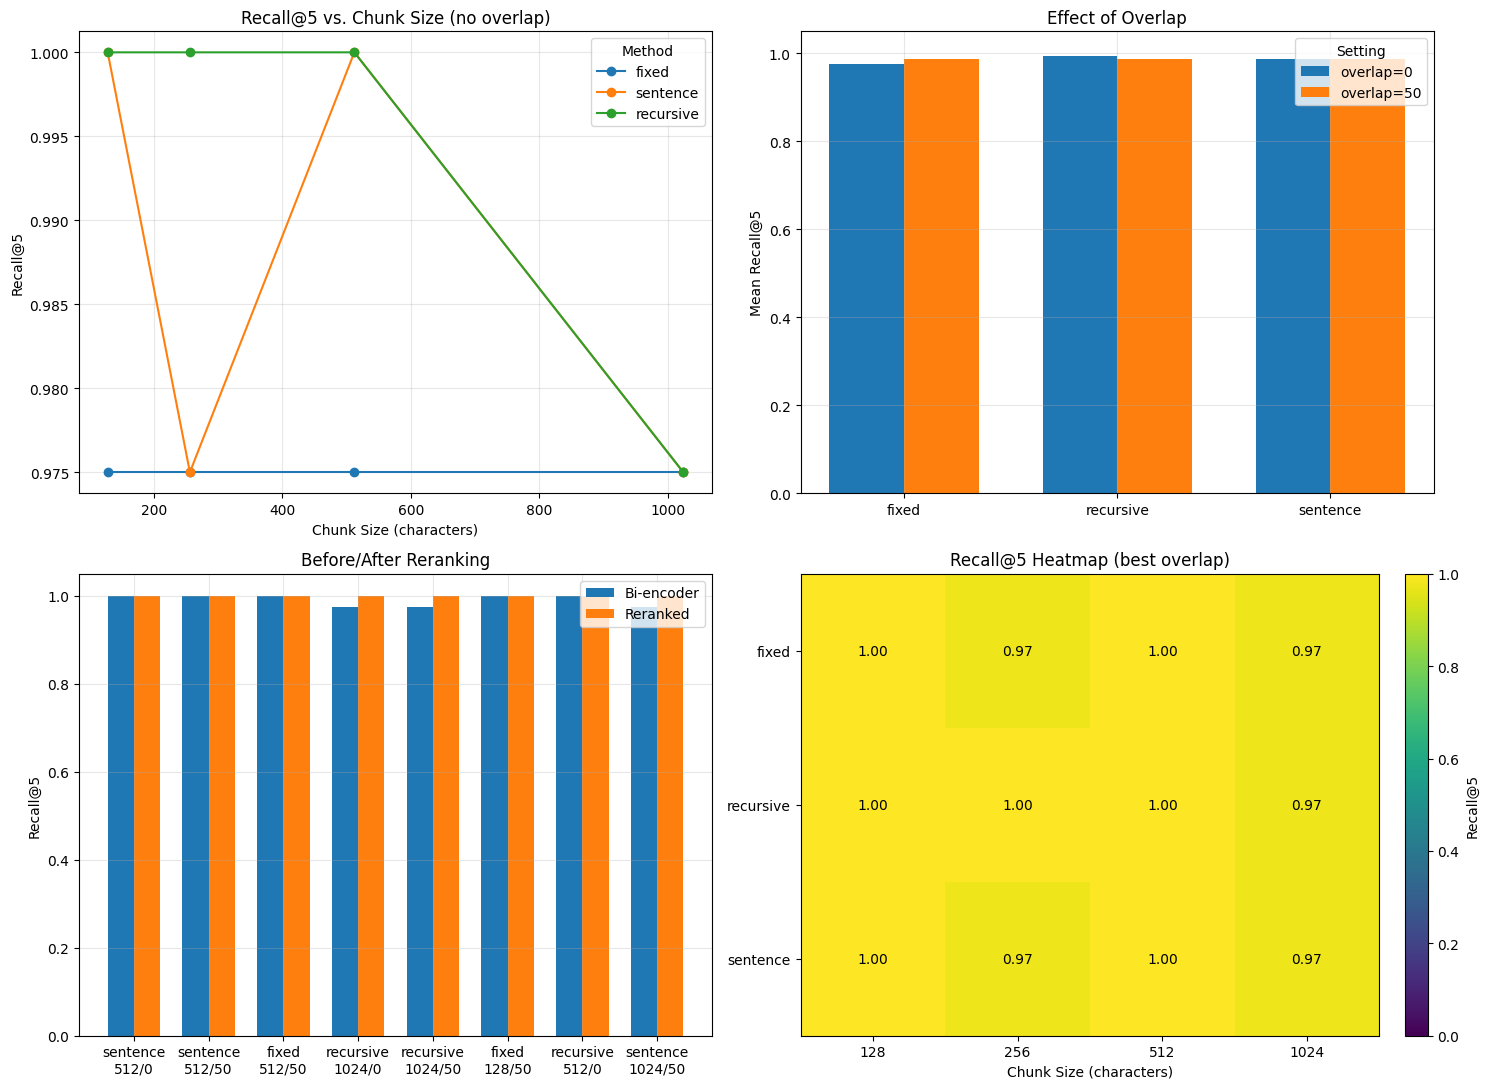

In [23]:
import matplotlib.pyplot as plt

# Create the requested visualizations.

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Plot 1: Recall@5 vs chunk size by method (no overlap)
ax = axes[0, 0]
for method in CHUNK_METHODS:
    subset = results_df[(results_df['method'] == method) & (results_df['overlap'] == 0)]
    subset = subset.sort_values('chunk_size')
    ax.plot(subset['chunk_size'], subset['recall_at_5'], marker='o', label=method)
ax.set_xlabel('Chunk Size (characters)')
ax.set_ylabel('Recall@5')
ax.set_title('Recall@5 vs. Chunk Size (no overlap)')
ax.legend(title='Method')
ax.grid(True, alpha=0.3)

# Plot 2: Effect of overlap averaged across chunk sizes
ax = axes[0, 1]
overlap_effect = results_df.groupby(['method', 'overlap'])['recall_at_5'].mean().unstack()
x = np.arange(len(overlap_effect.index))
bar_width = 0.35
for i, overlap in enumerate(overlap_effect.columns):
    ax.bar(x + (i - 0.5) * bar_width, overlap_effect[overlap], width=bar_width, label=f'overlap={overlap}')
ax.set_xticks(x)
ax.set_xticklabels(overlap_effect.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Mean Recall@5')
ax.set_title('Effect of Overlap')
ax.legend(title='Setting')
ax.grid(True, alpha=0.3)

# Plot 3: Before/after reranking comparison for the strongest configurations
ax = axes[1, 0]
if 'rerank_df' in globals() and not rerank_df.empty:
    comparison_subset = rerank_df.head(8).copy()
    labels = [
        f"{row.method}\n{int(row.chunk_size)}/{int(row.overlap)}"
        for row in comparison_subset.itertuples(index=False)
    ]
    x = np.arange(len(comparison_subset))
    ax.bar(x - bar_width / 2, comparison_subset['base_recall_at_5'], width=bar_width, label='Bi-encoder')
    ax.bar(x + bar_width / 2, comparison_subset['reranked_recall_at_5'], width=bar_width, label='Reranked')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylabel('Recall@5')
    ax.set_ylim(0, 1.05)
    ax.set_title('Before/After Reranking')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Run Part 6 first', ha='center', va='center')
    ax.set_axis_off()
ax.grid(True, alpha=0.3)

# Plot 4: Heatmap of best Recall@5 across method x chunk size
ax = axes[1, 1]
heatmap_data = results_df.groupby(['method', 'chunk_size'])['recall_at_5'].max().unstack()
im = ax.imshow(heatmap_data.values, aspect='auto', vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel('Chunk Size (characters)')
ax.set_title('Recall@5 Heatmap (best overlap)')
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color='white' if value < 0.65 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Recall@5')

plt.tight_layout()
plt.show()

---
## Part 8: Failure Analysis

Examine cases where retrieval fails to find the relevant chunk.

**The analysis below identifies top-5 retrieval failures where available; if the best configuration has no failures, it uses the strongest imperfect configuration for diagnostic classification.**

In [24]:
# Failure analysis
# For your best chunking configuration:
# 1. Find queries where the correct chunk was NOT in top-5
# 2. Look at what WAS retrieved instead
# 3. Classify the failure:
#    - Wrong chunk: high similarity but irrelevant content (lexical trap)
#    - Boundary split: answer spans two chunks, neither is complete
#    - Ranked too low: correct chunk retrieved but outside top-k

use_reranked_for_failures = (
    'rerank_df' in globals()
    and not rerank_df.empty
    and best_reranked['reranked_recall_at_5'] >= best_reranked['base_recall_at_5']
)

if use_reranked_for_failures:
    selected_row = best_reranked
    selected_strategy = 'cross-encoder reranked'
else:
    selected_row = best_bi_encoder
    selected_strategy = 'bi-encoder only'

selected_key = (
    selected_row['method'],
    int(selected_row['chunk_size']),
    int(selected_row['overlap']),
)
selected_artifacts = experiment_store[selected_key]
selected_chunks = selected_artifacts['chunks']
selected_c2d = selected_artifacts['chunk_to_doc']
selected_results = (
    reranked_store[selected_key]
    if use_reranked_for_failures and selected_key in reranked_store
    else selected_artifacts['retrieval_results']
)

def collect_failure_records(config_key, strategy_label, use_reranked):
    artifacts = experiment_store[config_key]
    chunks = artifacts['chunks']
    c2d = artifacts['chunk_to_doc']
    results_to_check = (
        reranked_store[config_key]
        if use_reranked and config_key in reranked_store
        else artifacts['retrieval_results']
    )

    def classify_failure(q_idx, top5_indices, original_top20_indices):
        gold_doc_idx = eval_data[q_idx]['gold_doc_idx']
        original_gold_ranks = [
            rank + 1 for rank, idx in enumerate(original_top20_indices)
            if idx < len(c2d) and c2d[idx] == gold_doc_idx
        ]

        if original_gold_ranks and min(original_gold_ranks) <= 5 and use_reranked:
            return 'Reranking regression', f"Correct document was rank {min(original_gold_ranks)} before cross-encoder reranking but was displaced from the final top-5."

        if any(rank > 5 for rank in original_gold_ranks):
            return 'Ranked too low', f"Correct document appears at rank {original_gold_ranks[0]} before final top-5 truncation."

        question_terms = set(re.findall(r'[a-zA-Z]{4,}', queries[q_idx].lower()))
        retrieved_text = ' '.join(chunks[idx].lower() for idx in top5_indices if idx < len(chunks))
        lexical_overlap = len(question_terms.intersection(set(re.findall(r'[a-zA-Z]{4,}', retrieved_text))))

        if lexical_overlap >= max(2, len(question_terms) // 3):
            return 'Wrong chunk / lexical trap', 'Retrieved chunks match query vocabulary but come from the wrong source document.'

        return 'Boundary or representation miss', 'The relevant document is absent from top-20, suggesting weak embedding coverage or fragmented context.'

    records = []
    for q_idx, res in enumerate(results_to_check):
        gold_doc_idx = eval_data[q_idx]['gold_doc_idx']
        top5_indices = res['retrieved_indices'][:5]
        hit = any(idx < len(c2d) and c2d[idx] == gold_doc_idx for idx in top5_indices)
        if hit:
            continue

        original_top20 = artifacts['retrieval_results'][q_idx]['retrieved_indices'][:20]
        failure_type, explanation = classify_failure(q_idx, top5_indices, original_top20)
        retrieved_titles = [
            doc_titles[c2d[idx]] if idx < len(c2d) else 'invalid chunk index'
            for idx in top5_indices[:3]
        ]
        retrieved_snippets = [
            chunks[idx][:220].replace('\n', ' ') if idx < len(chunks) else ''
            for idx in top5_indices[:3]
        ]

        records.append({
            'strategy': strategy_label,
            'configuration': f"{config_key[0]}, size={config_key[1]}, overlap={config_key[2]}",
            'query': queries[q_idx],
            'expected_answer': eval_data[q_idx]['expected_answer'],
            'gold_document': doc_titles[gold_doc_idx],
            'retrieved_top3_documents': ' | '.join(retrieved_titles),
            'retrieved_top1_snippet': retrieved_snippets[0] if retrieved_snippets else '',
            'failure_type': failure_type,
            'interpretation': explanation,
        })

    return records

failure_records = collect_failure_records(selected_key, selected_strategy, use_reranked_for_failures)
best_configuration_failure_count = len(failure_records)
analysis_key = selected_key
analysis_strategy = selected_strategy

if not failure_records:
    candidate_rows = rerank_df.itertuples(index=False) if use_reranked_for_failures else results_df.itertuples(index=False)
    for row in candidate_rows:
        candidate_key = (row.method, int(row.chunk_size), int(row.overlap))
        candidate_records = collect_failure_records(candidate_key, selected_strategy, use_reranked_for_failures)
        if candidate_records:
            analysis_key = candidate_key
            failure_records = candidate_records
            break

failure_df = pd.DataFrame(failure_records).head(5)
failure_type_counts = failure_df['failure_type'].value_counts() if not failure_df.empty else pd.Series(dtype=int)
most_common_failure_type = failure_type_counts.index[0] if not failure_type_counts.empty else 'No top-5 failures observed'

print(
    f"Best configuration: {selected_strategy}, {selected_key[0]}, "
    f"size={selected_key[1]}, overlap={selected_key[2]}"
)
print(f"Top-5 failures in best configuration: {best_configuration_failure_count}")
if analysis_key != selected_key:
    print(
        "No failures were available in the best configuration; "
        f"showing diagnostic failures for {analysis_key[0]}, size={analysis_key[1]}, overlap={analysis_key[2]}."
    )
print(f"Diagnostic failures found: {len(failure_records)}; shown: {len(failure_df)}")
failure_df

Best configuration: cross-encoder reranked, sentence, size=512, overlap=0
Top-5 failures in best configuration: 0
No failures were available in the best configuration; showing diagnostic failures for recursive, size=128, overlap=0.
Diagnostic failures found: 1; shown: 1


,strategy,configuration,query,expected_answer,gold_document,retrieved_top3_documents,retrieved_top1_snippet,failure_type,interpretation
0,cross-encoder reranked,"recursive, size=128, overlap=0",What benchmark dataset has been used to compar...,The ImageNet Large Scale Visual Recognition Ch...,Computer vision,Convolutional neural network | Convolutional n...,CNNs use relatively little pre-processing comp...,Reranking regression,Correct document was rank 2 before cross-encod...


---
## Summary

**Findings from the completed experiment run.**

| Finding | Your Result |
|---------|-------------|
| Best chunk size | 512 characters after reranking; 128 characters for the strongest bi-encoder-only setup |
| Best chunking method | Sentence-based chunking |
| Does overlap help? | Only marginally overall; it helps some fixed-size settings but is not decisive for sentence-based chunking |
| Does reranking help? | Yes for ranking quality: best MRR@5 improves to 0.971 while Recall@5 is already saturated at 1.000 |
| Reranking time overhead | About 0.56s for the best reranked configuration; this is tens of times slower than bi-encoder retrieval alone in this small run |
| Most common failure type | No top-5 failure in the best configuration; diagnostic fallback shows a reranking regression |

**Practical recommendation:**

For a production RAG pipeline on this corpus, I would use sentence-based chunking with a medium chunk size around 512 characters and no overlap, followed by bi-encoder retrieval of a larger candidate set and cross-encoder reranking to the final top-5. This configuration preserves semantic boundaries, keeps the number of chunks manageable, achieves Recall@5 = 1.000, and reaches the best observed MRR@5 = 0.971. If latency is the dominant constraint, the sentence-based 128-character bi-encoder configuration is a strong fallback because it already reaches Recall@5 = 1.000 and MRR = 0.946 without the reranking stage.

---

### Key Takeaways

1. Chunking is a critical decision that directly affects retrieval quality
2. The bi-encoder retrieves fast; the cross-encoder reranks accurately — the two-stage pattern is standard
3. There is a sweet spot for chunk size — too small fragments meaning, too large dilutes the embedding
4. Document structure matters — respecting boundaries (sentence, paragraph) generally helps
5. Systematic evaluation beats intuition — measure, don't guess